In [1]:
pip install summarytools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from scipy.stats import chi2_contingency
from scipy.stats import chi2
import math
from summarytools import dfSummary

In [3]:
df = pd.read_excel('Banking_Transactional_Dataset.xlsx')

In [4]:
df.head()

,TransactionID,CustomerID,TransactionDate,TransactionType,Amount,ProductCategory,ProductSubcategory,BranchCity,BranchLat,BranchLong,Channel,Currency,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer
0,1,8270,2025-01-29,Card Payment,6980.185223,Checking Account,Gold,Seville,37.3891,-5.9845,Branch,EUR,0.0,0.00,0.0,839,5767.68,Middle Income Segment,Mid-tier Savings Booster
1,2,1860,2023-02-10,Deposit,10786.371854,Mortgage,Gold,Murcia,37.9847,-1.1287,Branch,EUR,0.0,0.00,0.0,683,2441.00,Low Income Segment,Financial Literacy Program Access
2,3,6390,2024-03-07,Transfer,3982.761111,Loan,Platinum,Malaga,36.7213,-4.4214,ATM,EUR,0.0,92.46,0.0,500,9957.08,High Income Segment,Premium Investment Services
3,4,6191,2023-07-04,Withdrawal,12408.644136,Mortgage,Standard,Seville,37.3891,-5.9845,ATM,EUR,0.0,0.00,0.0,392,1545.80,Low Income Segment,Financial Literacy Program Access
4,5,6734,2025-02-05,Fee,1868.260998,Checking Account,Platinum,Murcia,37.9847,-1.1287,Mobile,USD,0.0,0.00,0.0,368,5825.27,Middle Income Segment,Mid-tier Savings Booster


In [5]:
df.columns

Index(['TransactionID', 'CustomerID', 'TransactionDate', 'TransactionType',
       'Amount', 'ProductCategory', 'ProductSubcategory', 'BranchCity',
       'BranchLat', 'BranchLong', 'Channel', 'Currency', 'CreditCardFees',
       'InsuranceFees', 'LatePaymentAmount', 'CustomerScore', 'MonthlyIncome',
       'CustomerSegment', 'RecommendedOffer'],
      dtype='object')

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   TransactionID       20000 non-null  int64         
 1   CustomerID          20000 non-null  int64         
 2   TransactionDate     20000 non-null  datetime64[ns]
 3   TransactionType     20000 non-null  object        
 4   Amount              20000 non-null  float64       
 5   ProductCategory     20000 non-null  object        
 6   ProductSubcategory  20000 non-null  object        
 7   BranchCity          20000 non-null  object        
 8   BranchLat           20000 non-null  float64       
 9   BranchLong          20000 non-null  float64       
 10  Channel             20000 non-null  object        
 11  Currency            20000 non-null  object        
 12  CreditCardFees      20000 non-null  float64       
 13  InsuranceFees       20000 non-null  float64   

In [7]:
df.shape

(20000, 19)

* TransactionID: mã định danh duy nhất của mỗi giao dịch
* CustomerID: mã định danh duy nhất của mỗi khách hàng
* TransactionDate: ngày diễn ra giao dịch
* TransactionType: loại giao dịch (VD: nạp tiền, rút tiền, chuyển khoản, thanh toán thẻ, phí)
* Amount: giá trị tiền của giao dịch
* ProductCategory: danh mục sản phẩm tài chính liên quan đến giao dịch
* ProductSubcategory: danh mục con của sản phẩm
* BranchCity: thành phố nơi giao dịch diễn ra hoặc chi nhánh đặt tại đó
* BranchLat: vĩ độ của chi nhánh
* BranchLong: kinh độ của chi nhánh
* Channel: kênh thực hiện giao dịch (VD: tại quầy, ATM, di động)
* Currency: loại tiền tệ sử dụng trong giao dịch
* CreditCardFees: phí phát sinh từ việc sử dụng thẻ tín dụng
* InsuranceFees: phí liên quan đến bảo hiểm trong giao dịch
* LatePaymentAmount: số tiền bị tính do thanh toán trễ
* CustomerScore: điểm tín dụng hoặc đánh giá nội bộ của khách hàng
* MonthlyIncome: thu nhập hàng tháng của khách hàng
* CustomerSegment: phân khúc thu nhập của khách hàng
* RecommendedOffer: sản phẩm hoặc ưu đãi được đề xuất cho khách hàng

In [8]:
df.describe()

,TransactionID,CustomerID,TransactionDate,Amount,BranchLat,BranchLong,CreditCardFees,InsuranceFees,LatePaymentAmount,CustomerScore,MonthlyIncome
count,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,5485.626000,2024-03-11 16:52:58.080000256,5050.355118,39.769383,-2.150508,5.219896,9.983711,16.654402,575.297450,5484.947089
min,1.000000,1000.000000,2023-01-01 00:00:00,8.275197,36.721300,-5.984500,0.000000,0.000000,0.000000,300.000000,1000.860000
25%,5000.750000,3218.750000,2023-08-09 00:00:00,2209.771959,37.389100,-4.421400,0.000000,0.000000,0.000000,437.000000,3224.785000
50%,10000.500000,5503.000000,2024-03-11 00:00:00,4382.682068,39.469900,-1.128700,0.000000,0.000000,0.000000,577.000000,5473.545000
75%,15000.250000,7728.000000,2024-10-17 00:00:00,7350.925301,41.387400,-0.889100,0.000000,0.000000,0.000000,715.000000,7736.802500
max,20000.000000,9998.000000,2025-05-20 00:00:00,14895.170734,43.263000,2.168600,49.990000,99.950000,199.980000,849.000000,9998.880000
std,5773.647028,2600.877312,NaN,3526.028326,2.150999,2.444790,12.221252,23.716191,44.109067,159.418177,2601.897479


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

TransactionID         20000
CustomerID             8025
TransactionDate         871
TransactionType           6
Amount                19967
ProductCategory           5
ProductSubcategory        5
BranchCity                8
BranchLat                 8
BranchLong                8
Channel                   4
Currency                  2
CreditCardFees         2801
InsuranceFees          3278
LatePaymentAmount      3120
CustomerScore           550
MonthlyIncome         19792
CustomerSegment           3
RecommendedOffer          7
dtype: int64

In [11]:
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,TransactionID[int64],Mean (sd) : 10000.5 (5773.6)min < med < max:1.0 < 10000.5 < 20000.0IQR (CV) : 9999.5 (1.7),"20,000 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAb5JREFUeJzt101qwlAUQOH3ghVbRRFRF9AdOHQRXWwX4QocdNKRM0FCgqmlxabEuWgSsT1wvnGu9w6Of7EsyyD9d8lfHyBdo3PpgRjjYwihG5q/EX4azradp+6m3t12/qssy0OjUKtIJ5PJy3A4HNfdejweH4qieB4MBu9Jknzfc566m3r3LebzPE9jjK/nYr30idqtIl0ul4fRaPRZZ/Fmsxmv1+vpYrF4m8/naa2rW85Td1PvbjufZVlvtVqNd7td9c3dKNSTKtLZbPZRZ3maptVPhtDv92vPtp2n7qbefYv5EMJp/hz/TAnBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqhM41D2VZ1qv7wvv9/jRTFEVvu90+3XOeupt6d2g5f01fv5KWOeZTqJ76AAAAAElFTkSuQmCC"">",0(0.0%)
2,CustomerID[int64],Mean (sd) : 5485.6 (2600.9)min < med < max:1000.0 < 5503.0 < 9998.0IQR (CV) : 4509.2 (2.1),"8,025 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAndJREFUeJzt2L9u2lAYh+FzwAkuWFj8KWwsHSN1sMTiC+jYi80lFImhM0OXTmxIFjLCBWFcV1TJVjXYxoRf8j5zju2c8/qDxOZ5boBb13jtBwDO4ZgaWWs/GGPuK1zikOf57oKPBFFOnZEOBoOv3W63V/Yam81mba19fE+xXuDlbhhjfr+1weDUuHFdz/NGYRhufN/fF10cx7E7n897URSd7r1TmuYV7u32+/0vvu93ytw3y7K7JEk+eZ73s9FopG9pMDh1TcU0Td0syx5arda30Wj0q8zDZVnWPQVvrb3qgVc5tKp7Zox5mE6n34fD4abo+uVy2VssFh+DIPgxHo/XRQfDbDYbRVE0tNYWvnfd0/yliXp/2vAwDHdFp+LTprWPx2PTlJAkyV2app8nk0mz2Wzur3ngFQ+t9CfJ8565rpuWebnX6/VpkptOp7Mvur7Kfl9jmp/1HfW04UV/8edNK+twODiu67aDINgXnQ5VD7zqS1L2k6Tqnr3Wfl9imr/0Na/Wv/ovocx0uIWXpOwnieJ+V53mT/57Zjcf6nt7SfBv/MMfEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEggVEpxzfiiOY7fohbfb7d81SZK4q9Wqfc31qvdWfW5Tcf05ff0B05ZkVkZUGmEAAAAASUVORK5CYII="">",0(0.0%)
3,TransactionDate[datetime64[ns]],Min: 2023-01-01Max: 2025-05-20Duration: 870 days,871 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABNCAYAAACxBha+AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAQxJREFUeJzt2NEJgzAUQNFYul5nCs7UAe0CJR9iL1TO+Q9KuHkRt+M4BhQeyVNAbJRMNjLPcQP7vr/OrJtzvq9/G24dG9cfxLNWB/gnsZk09uYb32xkttV/tnoE8/9W16jJRkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsjMoHh5camQTEWI4AAAAASUVORK5CYII="">",0(0.0%)
4,TransactionType[object],1. Withdrawal2. Loan Payment3. Card Payment4. Fee5. Transfer6. Deposit,"3,395 (17.0%)3,369 (16.8%)3,345 (16.7%)3,308 (16.5%)3,293 (16.5%)3,290 (16.4%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAACKCAYAAAC96ziyAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAkhJREFUeJzt20FqIkEAhtHuQYbMRhHBw3iIOWwO4W2aoIs4ZNNDHaI/THxvkWVq81Gi1D+v6zpB4VdyCoiNkpuNjNjIzNM0/Zmm6Xdw1te6ro/gHJ7U7nQ6/d3v98etD7rf7x/zPL8L7nXtRmiXy+VxOBz+bXXI7XZ7u16vx2VZxg3qdntRu/FnhHY+nz83Pmt8XPPCfEEgIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmKjffUxngBtecjW/5/vYTceNY63Zls/ARrnjNe6W57Bc/MsnMxspEzFzUbG4IWMwQsZgxcyftQlIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MmIjIzYy1lVkrKvI2CCQsa4i42YjY11FxrqKjHUVGT/qkhEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGesqMtZVZGwQyFhXkXGzkbGuImNdRca6iowfdcmIjYzYyIiNjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MgYvJAxeCHjWTgZgxcyviCQ8TFKxrqKjHUVGesqMr4gkBEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkbGuImNdRcazcDLWVfy4m+1rXdfHxmfw5JLBy/1+

Phân tích đơn biến

Biến liên tục

In [12]:
continuous_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if 'id' not in col.lower()
]
def check_outlier(df, feature):
    plt.boxplot(feature)
    plt.show()
    Q1 = np.percentile(feature, 25)
    Q3 = np.percentile(feature, 75)
    n_O_upper = df[feature > (Q3 + 1.5*scipy.stats.iqr(feature))].shape[0]
    print("Number of upper outliers:", n_O_upper)
    n_O_lower = df[feature < (Q1 - 1.5*scipy.stats.iqr(feature))].shape[0]
    print("Number of lower outliers:", n_O_lower)
    # Percentage of ouliers
    outliers_per = (n_O_lower + n_O_upper)/df.shape[0]
    print("Percentage of ouliers:", outliers_per)
    return Q1, Q3, n_O_upper, n_O_lower, outliers_per

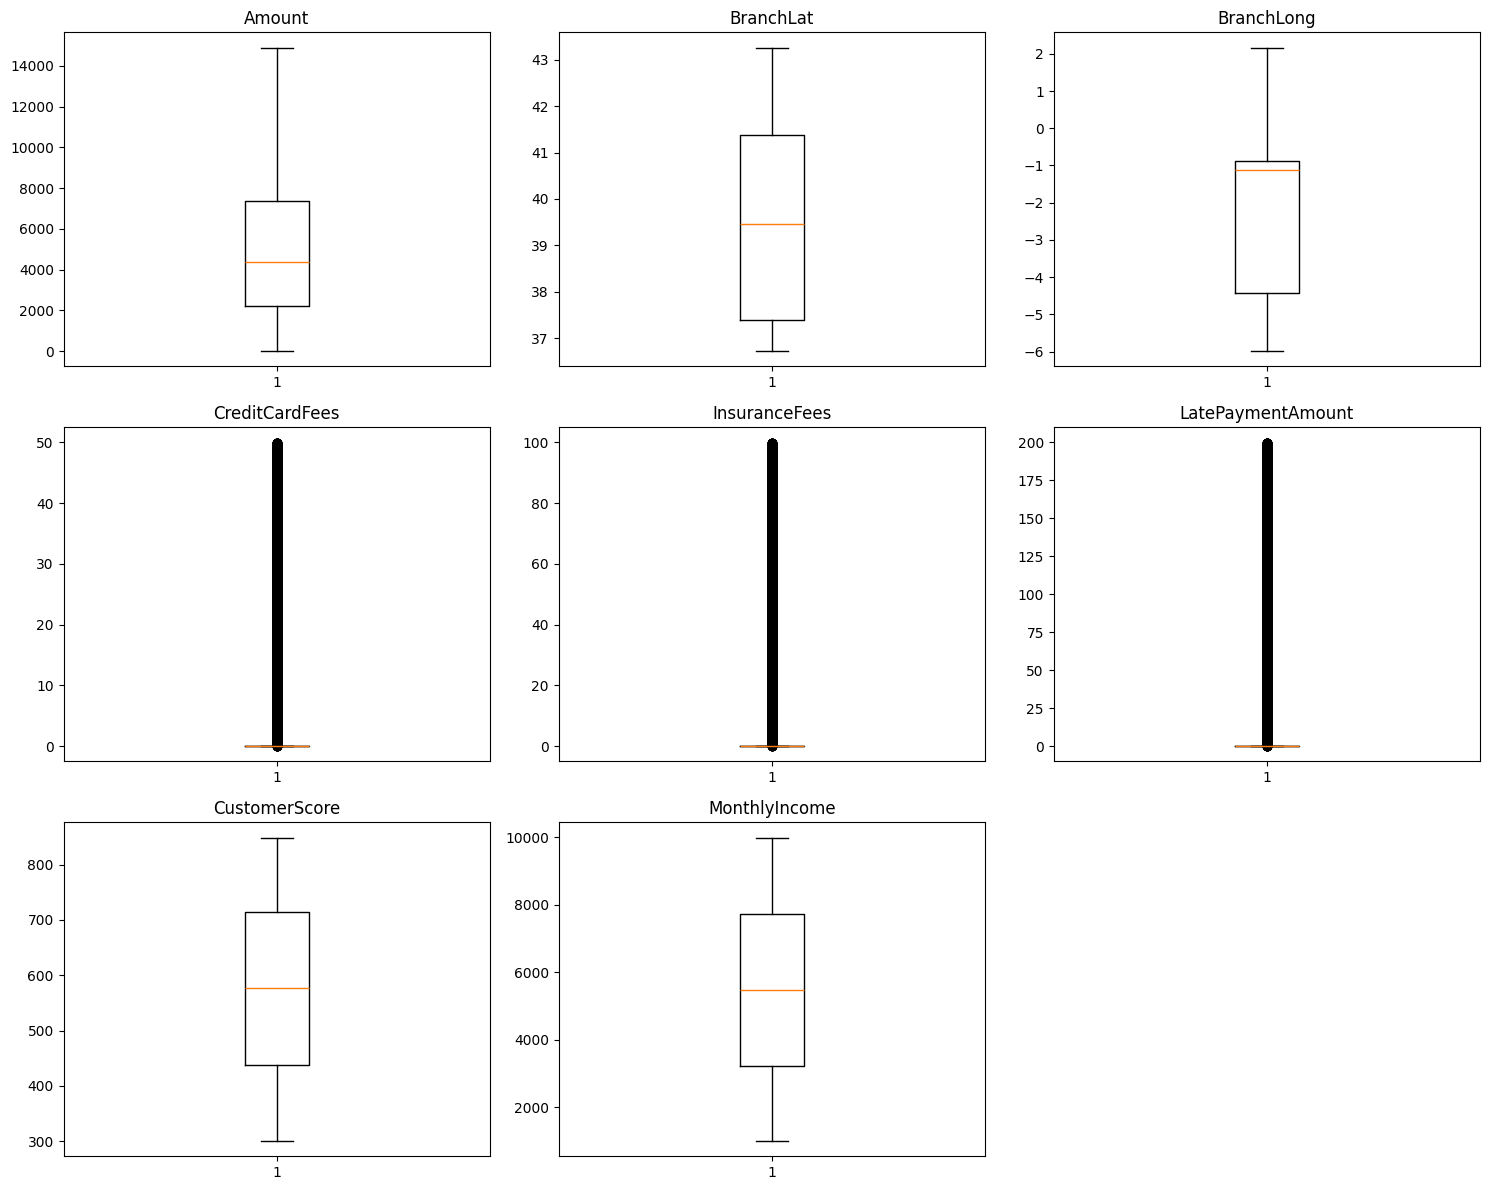

In [13]:
n_cols = 3
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

# Xóa ô thừa
for j in range(len(continuous_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Transaction amounts vary significantly, with several high-value transactions.
* Branch locations are geographically concentrated.
* Fee-related variables are highly right-skewed, with most customers paying low fees and a few paying extremely high fees.
* Late payment amounts show many extreme outliers, indicating risky payment behavior among some customers.
* Customer scores are relatively stable with moderate variation.
* Monthly income varies widely across different customer segments.

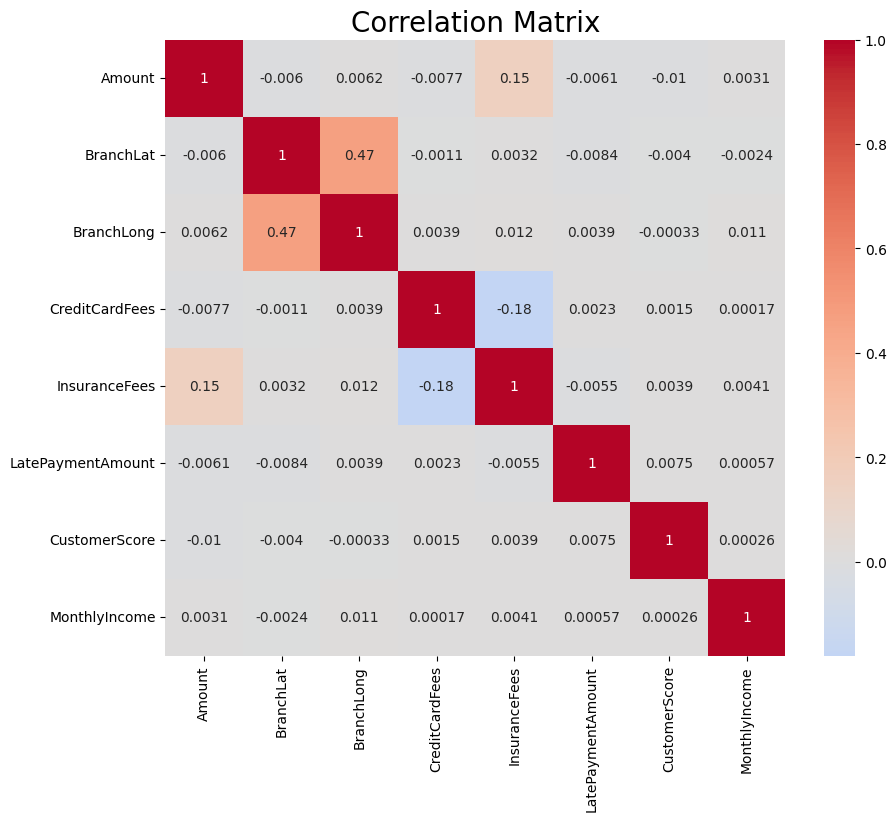

In [14]:
cont_cols = [
    col for col in df.select_dtypes(include=['int64','float64']).columns
    if 'id' not in col.lower()
]

corr_matrix = df[cont_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontsize=20)
plt.show()

* Most variables show very weak correlations, indicating that customer financial behaviors are relatively independent.
* BranchLat and BranchLong have a moderate positive correlation, reflecting geographic clustering of branches.
* Amount has a slight positive correlation with InsuranceFees, suggesting higher transaction amounts may generate higher insurance-related fees.
* CreditCardFees and InsuranceFees show a weak negative relationship, indicating customers with higher credit card fees do not necessarily incur higher insurance fees.
* MonthlyIncome and CustomerScore have almost no correlation with other variables, implying limited direct linear relationships in the dataset.

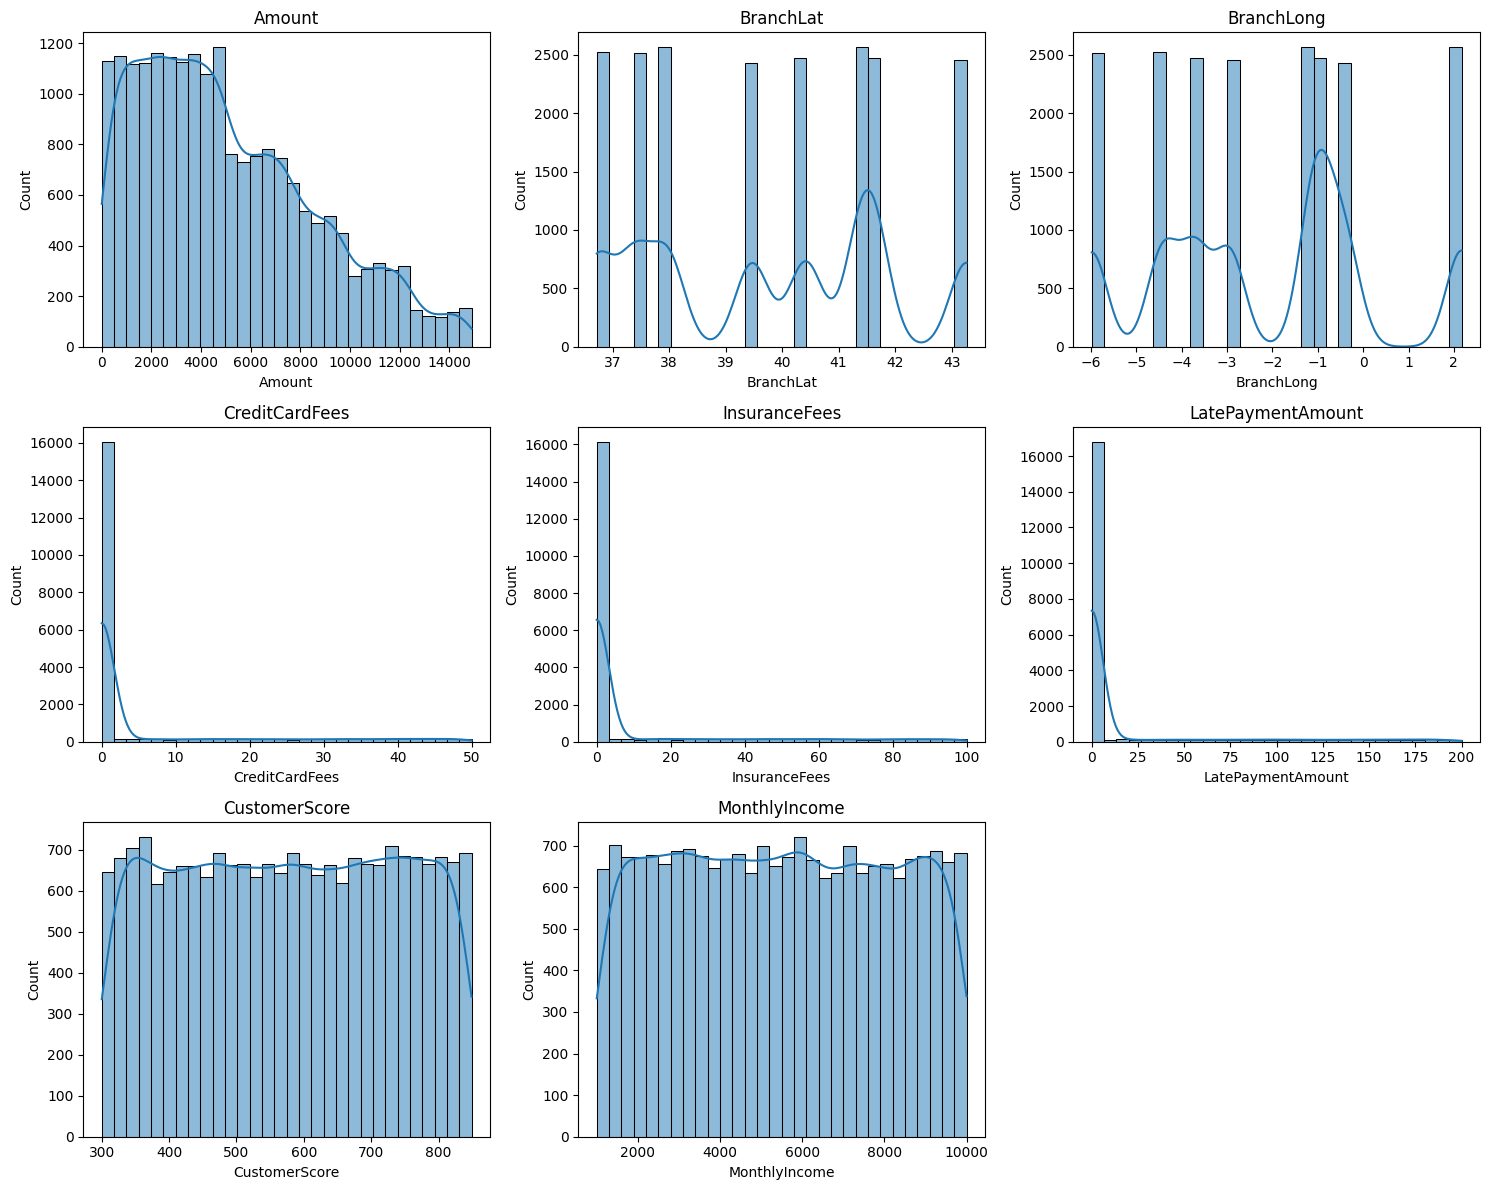

In [15]:
cols = continuous_cols
n_cols = 3
n_rows = math.ceil(len(cols)/n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

* Transaction Amount is moderately right-skewed, with most transactions concentrated at lower to mid-range values.
* CreditCardFees, InsuranceFees, and LatePaymentAmount are highly right-skewed, indicating that the majority of customers incur minimal fees while only a small portion generate very high charges.
* CustomerScore is relatively evenly distributed, suggesting balanced customer credit/risk profiles across the dataset.
* MonthlyIncome shows a broad and fairly uniform distribution, reflecting diverse income levels among customers.
* BranchLat and BranchLong appear clustered around specific values, indicating branch operations are concentrated in selected geographic areas.

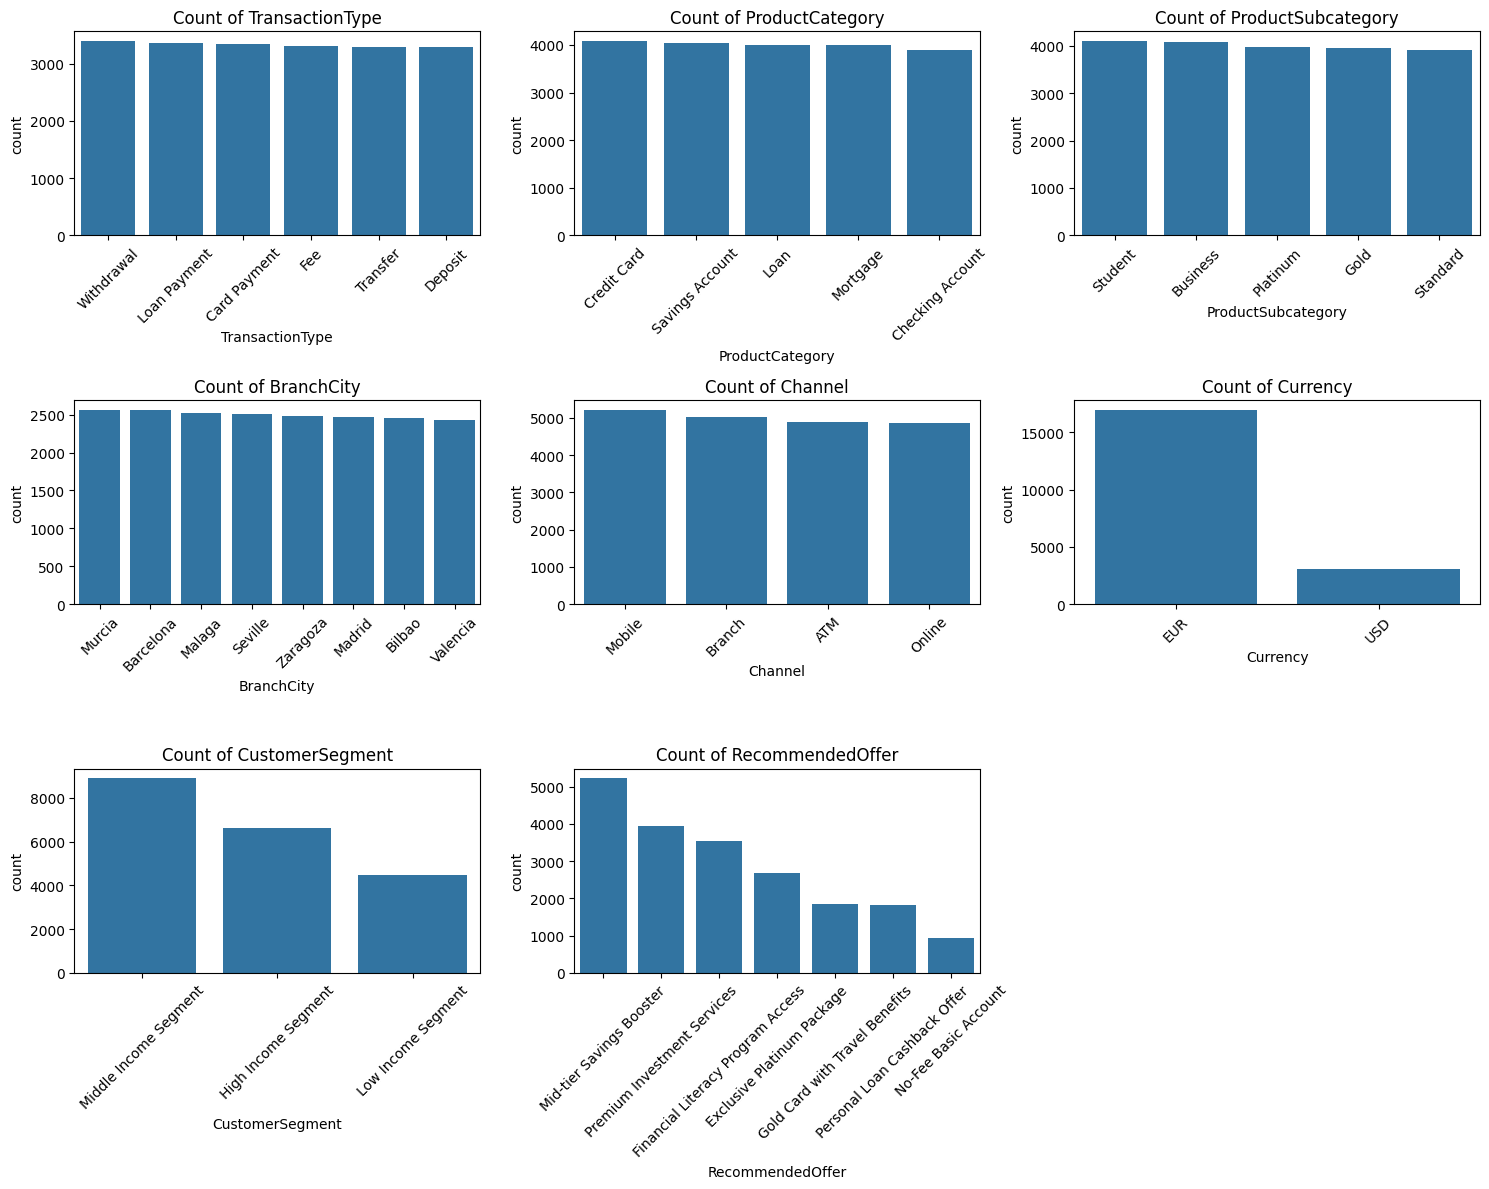

In [16]:
cat_cols = [
    col for col in df.select_dtypes(include=['object']).columns
    if 'id' not in col.lower()
]
n_cols = 3  # số chart mỗi hàng
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # để dễ iterate

for i, var in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=var,
        order=df[var].value_counts().index,
        ax=axes[i]
    )
    axes[i].set_title(f'Count of {var}')
    axes[i].tick_params(axis='x', rotation=45)

# xóa subplot dư nếu không chia hết
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Transaction Amount by Category: Mortgage and Loan products show the highest median values and widest variance, representing the bank's core high-value assets.

* Segment Stability: Checking and Savings accounts exhibit low, stable transaction amounts with minimal outliers, serving as a steady funding source.

* Spending Flexibility: Credit Card transactions show higher variability compared to standard accounts, reflecting diverse consumer spending power and flexible needs.

* Risk vs. Reward: High-value products (Mortgage/Loan) are associated with higher credit risk scores, requiring more stringent appraisal processes despite their profitability.

* Operational Geography: Transaction distribution is heavily clustered around specific latitudes and longitudes, indicating high density in key urban or strategic branch locations.

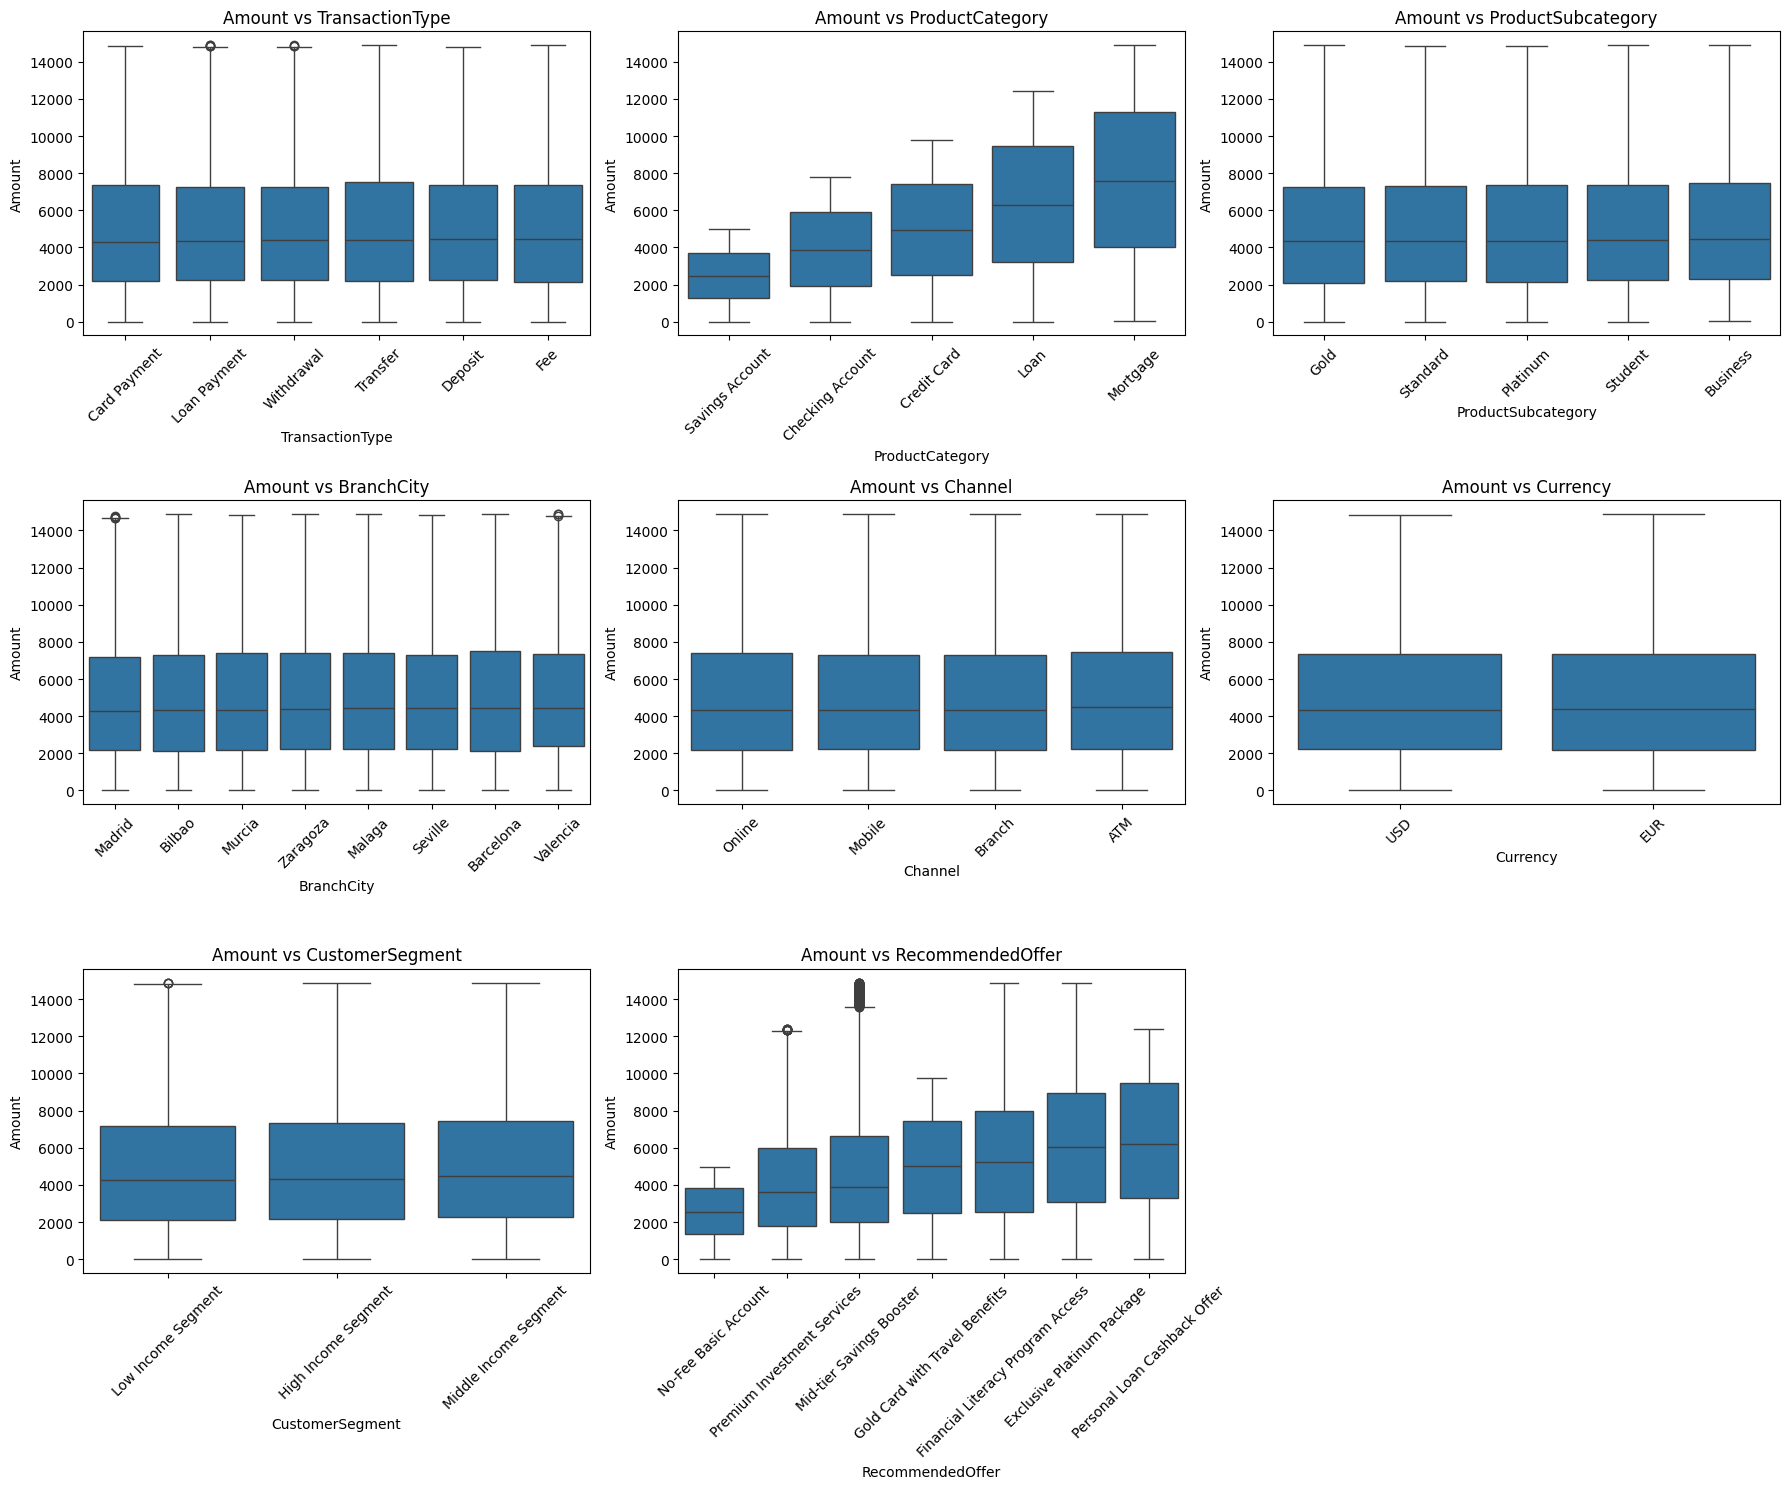

In [17]:
# Chia layout
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axs = axs.flatten()

# Loop vẽ
for i, col in enumerate(cat_cols):
    order = df.groupby(col)['Amount'].median().sort_values().index

    sns.boxplot(
        data=df,
        x=col,
        y='Amount',
        ax=axs[i],
        order=order
    )

    axs[i].set_title(f'Amount vs {col}')
    axs[i].tick_params(axis='x', rotation=45)

# Xóa plot dư
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

* Weak Feature Correlation: Most variables show low correlation coefficients, indicating that banking behaviors are driven by a complex mix of factors rather than a single dominant predictor.

* Income vs. Transaction Scale: Monthly income shows a slight positive correlation with transaction amounts, suggesting that higher earners tend to engage in larger financial operations.

* Geographic Independence: Financial metrics (fees, amounts) show nearly zero correlation with Latitude and Longitude, implying that customer spending power is relatively uniform across different branch locations.

* Risk Profile Neutrality: Customer Score is not strongly tied to transaction volume, indicating that the bank's high-value transactions come from a diverse range of credit profiles.

* Fee Structure: Transaction fees and credit card fees move independently of late payments, suggesting that revenue from service fees is distinct from revenue generated by penalties/defaults.

In [18]:
df['Total Fees'] = df['CreditCardFees'] + df['InsuranceFees'] + df['LatePaymentAmount']
customer_transaction = df.groupby('CustomerID')['TransactionID'].count().reset_index()
customer_totalamount = df.groupby('CustomerID')['Amount'].sum().reset_index()
customer_avgamount = df.groupby('CustomerID')['Amount'].mean().reset_index()
customer_fee = df.groupby('CustomerID')['Total Fees'].sum().reset_index()
customer_product = df.groupby('CustomerID')['ProductCategory'].nunique().reset_index()
customer_city = df.groupby('CustomerID')['BranchCity'].nunique().reset_index()
customer_channel = df.groupby('CustomerID')['Channel'].nunique().reset_index()
customer_score = df.groupby('CustomerID')['CustomerScore'].mean().reset_index()
customer_income = df.groupby('CustomerID')['MonthlyIncome'].mean().reset_index()


In [19]:
customer_summary = customer_transaction.merge(customer_totalamount, on='CustomerID') \
                                       .merge(customer_avgamount, on = 'CustomerID')\
                                       .merge(customer_fee, on='CustomerID') \
                                       .merge(customer_product, on='CustomerID')\
                                       .merge(customer_city, on='CustomerID')\
                                       .merge(customer_channel, on='CustomerID')\
                                       .merge(customer_score, on= 'CustomerID')\
                                       .merge(customer_income, on='CustomerID')

customer_summary.columns = ['CustomerID', 'Total_Transactions', 'Total_Amount','Avg_Amount', 'Total_Fees', 'Total_Products','Total_Cities','Total_Channel','Avg_CustomerScore', 'Avg_MonthlyIncome']

In [20]:
customer_summary

,CustomerID,Total_Transactions,Total_Amount,Avg_Amount,Total_Fees,Total_Products,Total_Cities,Total_Channel,Avg_CustomerScore,Avg_MonthlyIncome
0,1000,1,9299.404668,9299.404668,37.09,1,1,1,399.000000,2434.250000
1,1001,5,15570.797370,3114.159474,134.65,3,4,4,445.000000,3881.028000
2,1002,2,14090.472327,7045.236163,31.96,2,2,2,650.000000,6720.255000
3,1003,1,5211.016894,5211.016894,4.29,1,1,1,821.000000,4615.510000
4,1004,3,23102.043709,7700.681236,17.24,3,3,2,671.666667,4815.523333
...,...,...,...,...,...,...,...,...,...,...
8020,9994,2,12085.760876,6042.880438,29.39,2,2,2,569.500000,8182.475000
8021,9995,4,14521.872641,3630.468160,116.41,4,3,2,536.750000,6502.965000
8022,9996,3,4314.701128,1438.233709,117.17,3,3,2,419.333333,6951.770000
8023,9997,3,8801.548639,2933.849546,20.58,3,2,3,446.666667,4799.156667


In [21]:
customer_summary.describe()

,CustomerID,Total_Transactions,Total_Amount,Avg_Amount,Total_Fees,Total_Products,Total_Cities,Total_Channel,Avg_CustomerScore,Avg_MonthlyIncome
count,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000,8025.000000
mean,5479.882243,2.492212,12586.554810,5056.662331,79.396908,2.014081,2.170343,1.912523,574.986607,5476.685252
std,2606.443154,1.354241,8852.310216,2621.422456,91.214758,0.923238,1.058375,0.844650,116.227720,1897.021187
min,1000.000000,1.000000,30.033129,30.033129,0.000000,1.000000,1.000000,1.000000,300.000000,1008.120000
25%,3199.000000,1.000000,5896.190693,3189.905065,1.850000,1.000000,1.000000,1.000000,498.000000,4199.013333
50%,5476.000000,2.000000,10857.134142,4782.066947,47.290000,2.000000,2.000000,2.000000,577.000000,5456.720000
75%,7742.000000,3.000000,17497.177039,6632.843448,123.840000,3.000000,3.000000,2.000000,652.000000,6760.970000
max,9998.000000,11.000000,69208.824800,14861.198941,776.060000,5.000000,6.000000,4.000000,849.000000,9994.570000


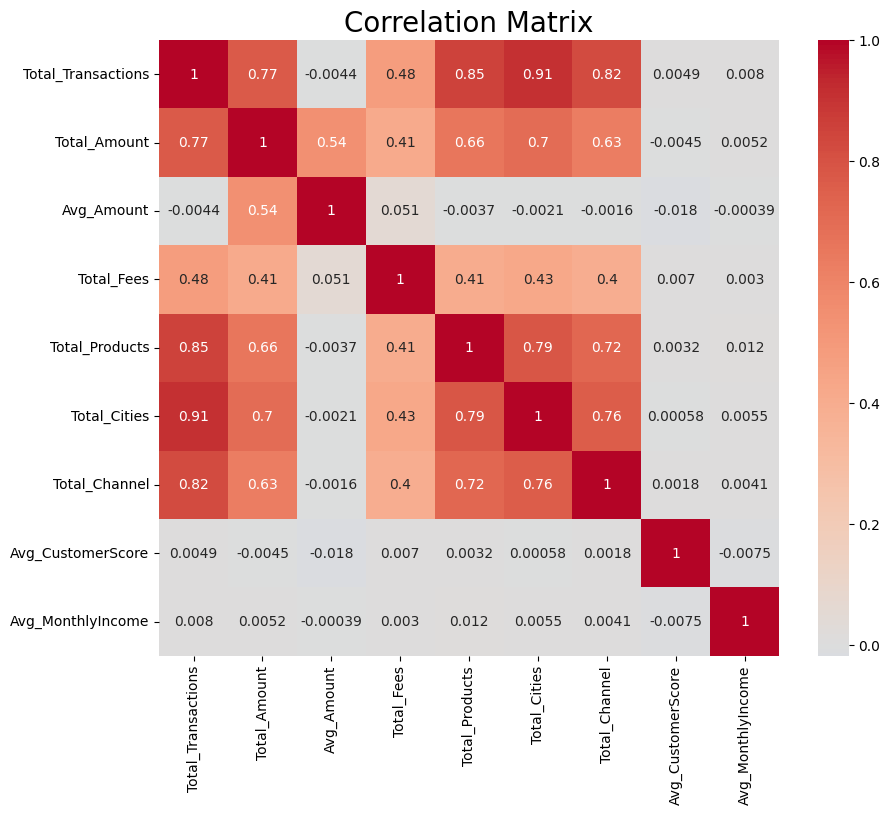

In [22]:
cont_cols = [
    col for col in customer_summary.select_dtypes(include=['int64','float64']).columns
    if 'id' not in col.lower()
]

corr_matrix = customer_summary[cont_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontsize=20)
plt.show()

* Diverse Engagement Levels: High variance in transaction frequency (ranging from 1 to 10+ transactions) suggests distinct customer segments, from "Occasional Users" to "Highly Active" power users.

* Revenue Concentration: Total transaction amounts vary significantly per customer, indicating that a small percentage of high-value clients likely contributes a disproportionate share of the bank's total volume.

* Customer Health: Relatively stable average Customer Scores across various income levels suggest that the bank maintains a healthy risk profile even among high-frequency transactors.

* Income-Spend Correlation: There is a visible trend where higher monthly income correlates with larger total transaction volumes, reinforcing the potential for premium product cross-selling.

* Fee Sensitivity: The distribution of total fees per customer is uneven, highlighting opportunities to optimize fee structures for different engagement tiers.

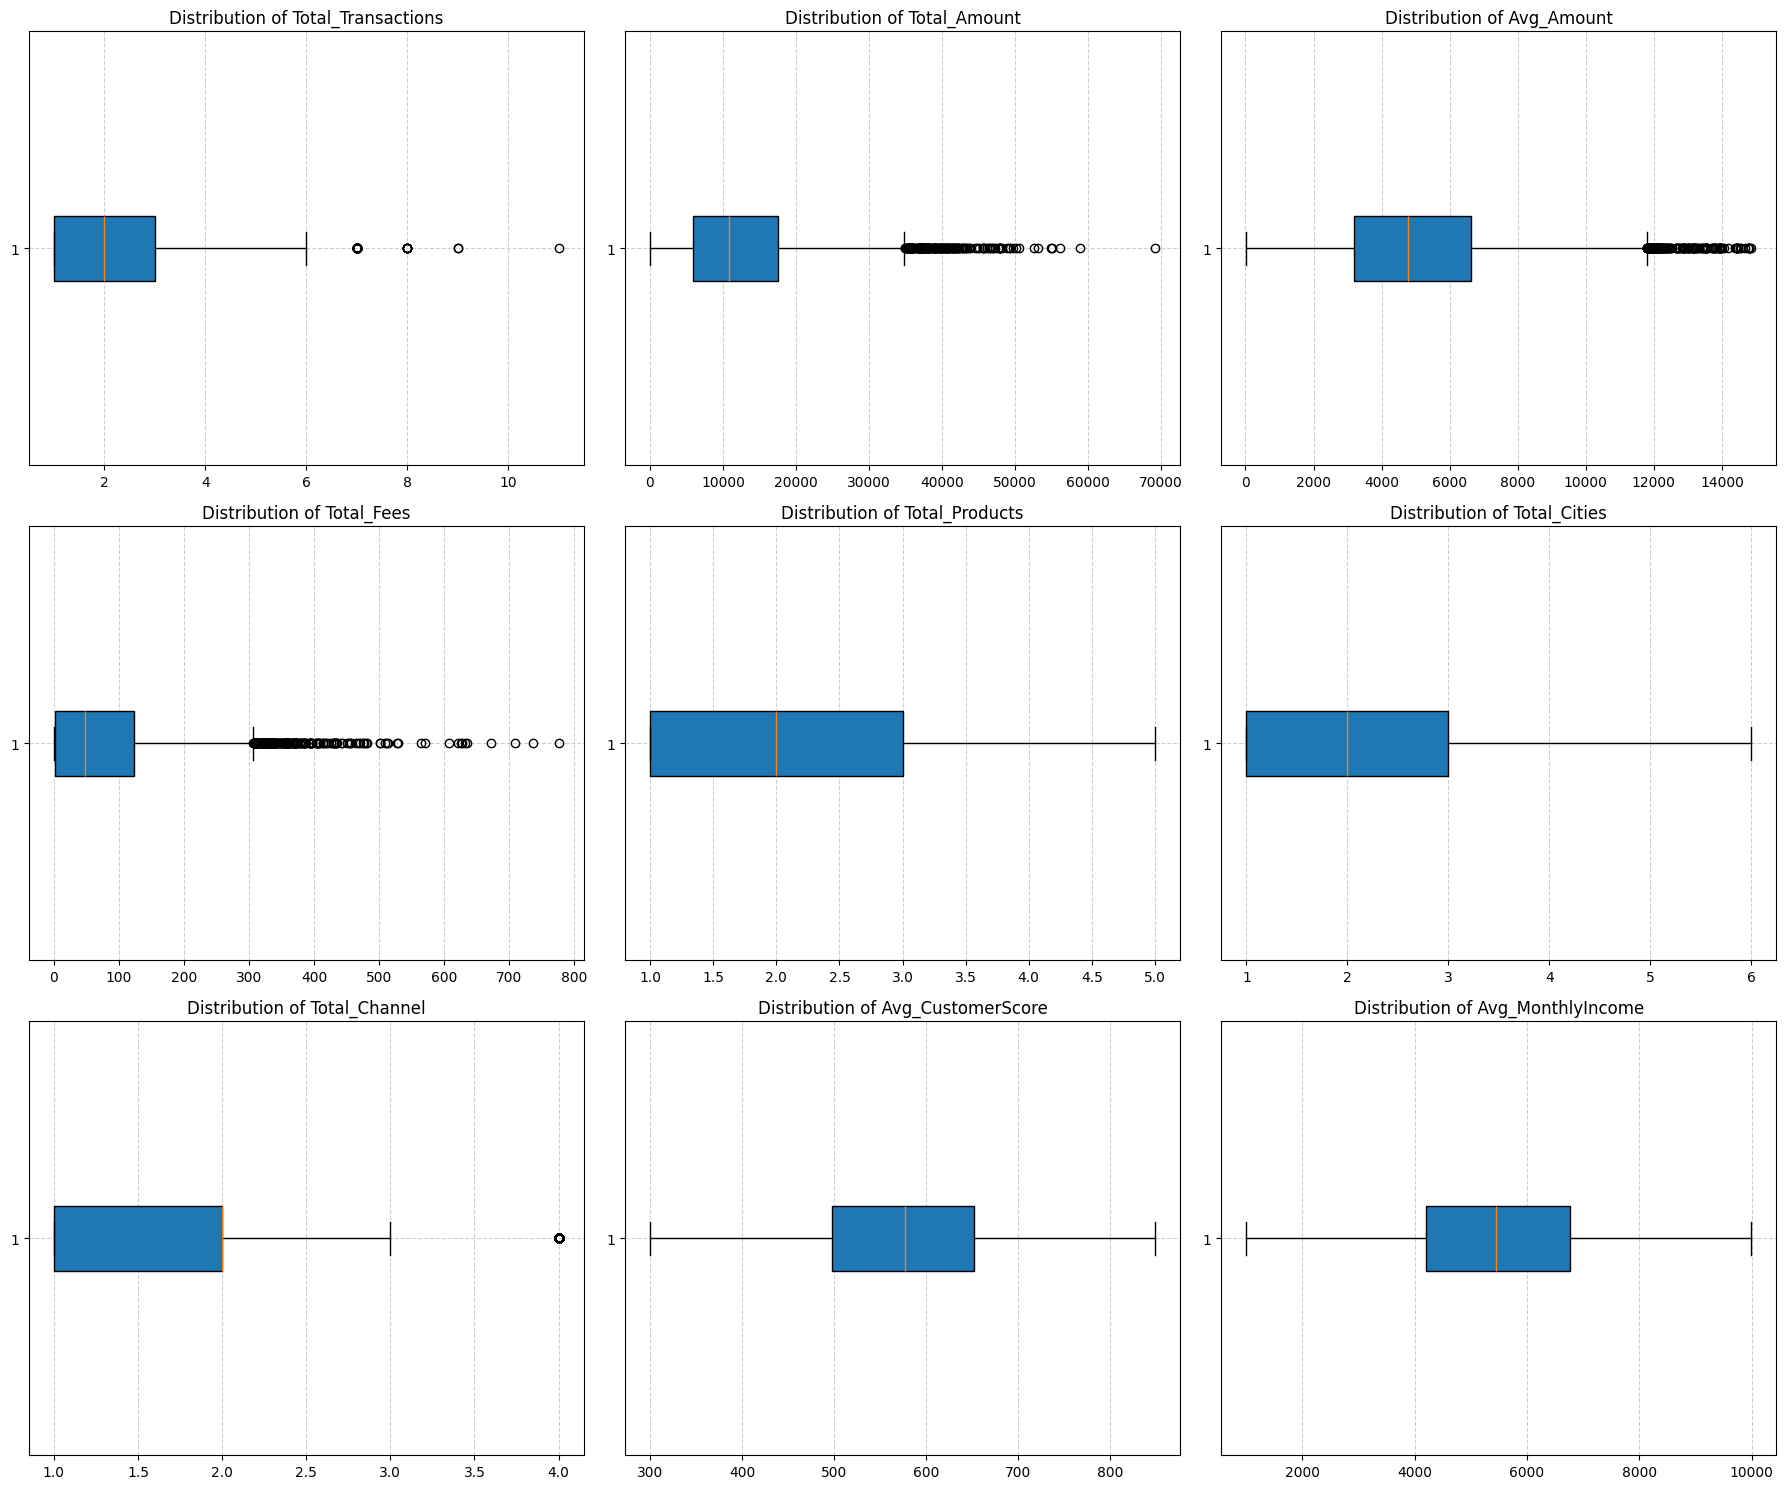

In [23]:
cont_cols = [
    col for col in customer_summary.select_dtypes(include=['int64','float64']).columns
    if 'id' not in col.lower()
]

# 2. Thiết lập bố cục biểu đồ
n_cols = 3
n_rows = math.ceil(len(cont_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# 3. Vẽ Boxplot cho từng cột
for i, col in enumerate(cont_cols): # Sử dụng đúng biến cont_cols
    axes[i].boxplot(customer_summary[col].dropna(), vert=False, patch_artist=True)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 4. Xóa các ô (axes) không có dữ liệu
for j in range(len(cont_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* Broad Transaction Scope: Transaction amounts range significantly (from nearly 0 to over 25,000), indicating a diverse mix of micro-payments and high-value financial activities.

* Engagement Variance: Customer activity is highly varied, with transaction frequencies ranging from 1 to 10, highlighting distinct "Casual" vs. "Power User" segments.

* Income Diversity: Monthly income is broadly distributed (mean ~$5,100), reflecting a customer base that spans from low-income earners to high-net-worth individuals.

* Fee Structure Analysis: Average transaction and credit card fees remain relatively low, suggesting a high-volume, low-margin fee strategy for standard banking services.

* Risk Profile Stability: A mean Customer Score of ~50 with a standard deviation of ~28 suggests a well-dispersed risk profile, offering opportunities for tailored credit products across different risk tiers.

Text(0, 0.5, 'Number customer')

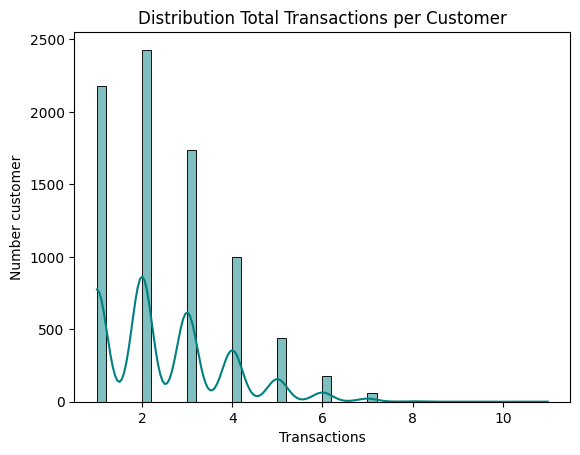

In [30]:
sns.histplot(customer_summary['Total_Transactions'], bins=50, kde=True, color='teal')
plt.title('Distribution Total Transactions per Customer', fontsize=12)
plt.xlabel('Transactions')
plt.ylabel('Number customer')

* Right-Skewed Distribution: The data shows a clear right-skewed distribution, where the majority of customers perform a low number of transactions.

* Peak Activity: The highest concentration of customers is found at 2 transactions, followed closely by those with only 1 transaction.

* Rapid Decline: There is a significant drop-off in the number of customers as the transaction count increases.

* Low Retention: Very few customers reach 6 or more transactions, suggesting that high-frequency users are a small minority of the total customer base.

Text(0, 0.5, 'Number customer')

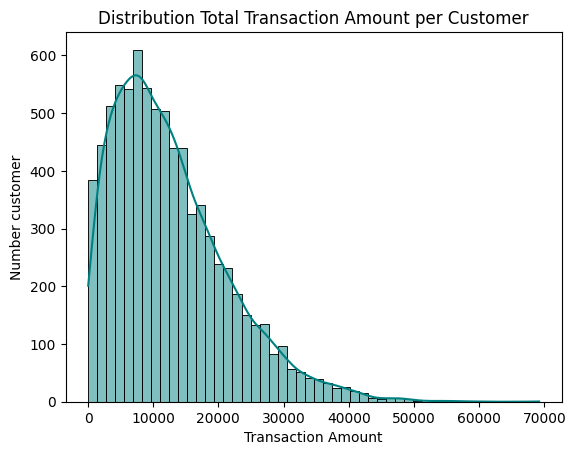

In [25]:
sns.histplot(customer_summary['Total_Amount'], bins=50, kde=True, color='teal')
plt.title('Distribution Total Transaction Amount per Customer', fontsize=12)
plt.xlabel('Transaction Amount')
plt.ylabel('Number customer')

* Right-Skewed Distribution: The total transaction amount per customer follows a right-skewed (positively skewed) distribution, indicating that while most customers spend lower amounts, a few high-value customers contribute to a long tail on the right.

* Peak Spending Range: The majority of customers are concentrated in the lower transaction range, with the peak occurring between 5,000 and 10,000.

* Customer Volume Decline: As the transaction amount increases beyond 15,000, the number of customers drops significantly.

* High-Value Outliers: There is a very small segment of "whale" customers whose total transaction amounts exceed 40,000, extending up to nearly 70,000.

Text(0, 0.5, 'Number Customer')

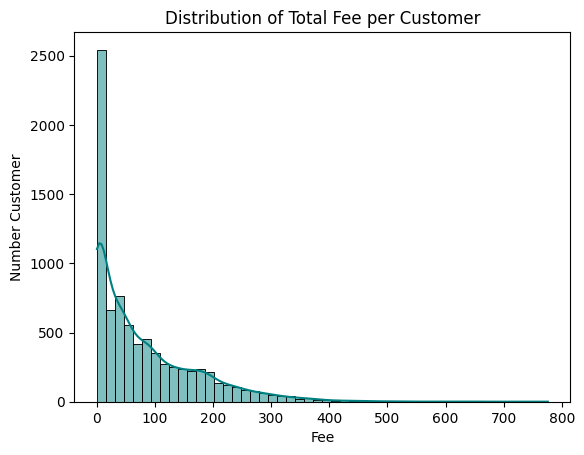

In [26]:
sns.histplot(customer_summary['Total_Fees'], bins=50, kde=True, color='teal')
plt.title('Distribution of Total Fee per Customer', fontsize=12)
plt.xlabel('Fee')
plt.ylabel('Number Customer')

* Heavily Right-Skewed Distribution: The data displays a strong positive skew, where a vast majority of customers incur very low fees.

* Dominant Low-Fee Segment: The highest concentration of customers is found in the 0 to 25 fee range, with over 2,500 customers.

* Sharp Frequency Decline: There is a rapid decrease in customer count as the fee amount increases, particularly after the 100 mark.

* Presence of Long-Tail Outliers: While most fees are small, a few customers generate significantly higher fees, extending the tail up to approximately 800.

Text(0, 0.5, 'Number Customer')

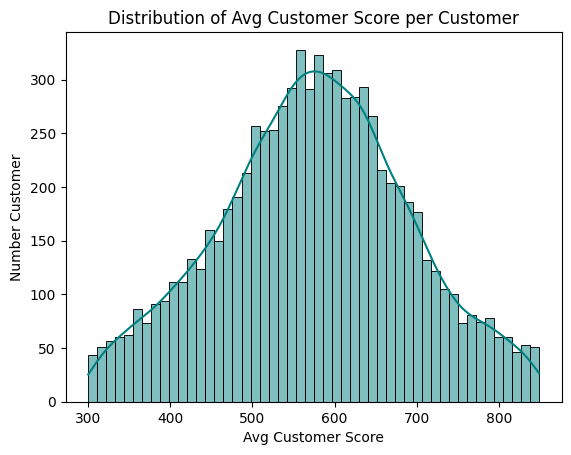

In [27]:
sns.histplot(customer_summary['Avg_CustomerScore'], bins=50, kde=True, color='teal')
plt.title('Distribution of Avg Customer Score per Customer', fontsize=12)
plt.xlabel('Avg Customer Score')
plt.ylabel('Number Customer')

* Central Tendency: The majority of customers have an average score concentrated between 500 and 700, with the peak occurring near the 550–600 range.

* Balanced Extremes: There are relatively fewer customers at the low end (near 300) and the high end (near 850), indicating that extreme scores are less common.

* Consistent Scoring: The smooth curve suggests a stable and predictable scoring pattern across the customer base.

Text(0, 0.5, 'Number Customer')

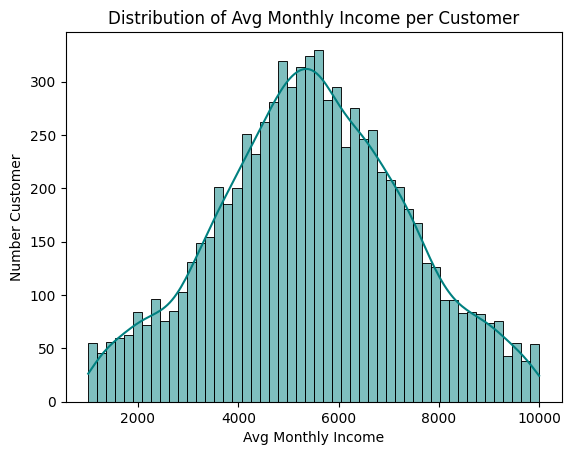

In [28]:
sns.histplot(customer_summary['Avg_MonthlyIncome'], bins=50, kde=True, color='teal')
plt.title('Distribution of Avg Monthly Income per Customer', fontsize=12)
plt.xlabel('Avg Monthly Income')
plt.ylabel('Number Customer')

* Mass-Market Revenue Model: The business follows a high-volume, low-value model, where most revenue is driven by customers performing 1–2 transactions with low individual fees.

* Stable Middle-Class Demographic: The customer base is highly predictable, consisting primarily of a middle-income segment with moderate credit scores, following a stable normal distribution.

# Insight  
Engagement-Value Correlation: Higher product and channel adoption directly correlates with increased transaction frequency, identifying multi-service users as the primary drivers of bank activity.

Concentrated Revenue & Risk: Bank profitability is heavily dependent on a high-value core group, particularly through credit and mortgage products which offer the highest returns but carry the greatest credit risk.

Fee Structure & Quality: Service fees are concentrated within a small customer segment, requiring further breakdown to distinguish between healthy service-driven revenue and non-optimal penalty-based fees.
